<a href="https://colab.research.google.com/github/Satyabratadas/GeoEmerge_hackathon/blob/master/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd                           # For working with data
pd.set_option("display.max_columns", None)    # Lets us see all columns of the data instead of just a preview
import geopandas as gpd                       # For working with spatial data
import numpy as np                            # For working with numbers
import matplotlib.pyplot as plt               # For making graphs
from datetime import date                     # For formatting dates
from PIL import Image                         # For getting and displaying images from links
import requests                               # For getting information from links
from io import BytesIO                        # For working with types of input and output

import seaborn as sns
import folium
from folium.plugins import HeatMap


end_date = "2026-01-31"

data = gpd.read_file(f"https://api.globe.gov/search/v1/measurement/?protocols=mosquito_habitat_mapper&datefield=measuredDate&startdate=2018-01-01&enddate={end_date}&geojson=TRUE&sample=FALSE")

In [17]:
land_cover = gpd.read_file(f"https://api.globe.gov/search/v1/measurement/?protocols=land_covers&datefield=measuredDate&startdate=2018-01-01&enddate={end_date}&geojson=TRUE&sample=FALSE")

In [ ]:
land_cover

,countryCode,countryName,elevation,landcoversDataSource,landcoversDownwardCaption,landcoversDownwardExtraData,landcoversDownwardPhotoUrl,landcoversDryGround,landcoversEastCaption,landcoversEastClassifications,landcoversEastExtraData,landcoversEastPhotoUrl,landcoversFeature1Caption,landcoversFeature1ExtraData,landcoversFeature1PhotoUrl,landcoversFeature2Caption,landcoversFeature2ExtraData,landcoversFeature2PhotoUrl,landcoversFeature3Caption,landcoversFeature3ExtraData,landcoversFeature3PhotoUrl,landcoversFeature4Caption,landcoversFeature4ExtraData,landcoversFeature4PhotoUrl,landcoversFieldNotes,landcoversGlobeTeams,landcoversLandCoverId,landcoversLeavesOnTrees,landcoversLocationAccuracyM,landcoversLocationMethod,landcoversMeasuredAt,landcoversMeasurementElevation,landcoversMeasurementLatitude,landcoversMeasurementLongitude,landcoversMucCode,landcoversMucDescription,landcoversMucDetails,landcoversMuddy,landcoversNorthCaption,landcoversNorthClassifications,landcoversNorthExtraData,landcoversNorthPhotoUrl,landcoversRainingSnowing,landcoversSnowIce,landcoversSouthCaption,landcoversSouthClassifications,landcoversSouthExtraData,landcoversSouthPhotoUrl,landcoversStandingWater,landcoversUpwardCaption,landcoversUpwardExtraData,landcoversUpwardPhotoUrl,landcoversUserid,landcoversWestCaption,landcoversWestClassifications,landcoversWestExtraData,landcoversWestPhotoUrl,organizationId,organizationName,protocol,siteId,siteName,geometry
0,USA,United States,6.9,GLOBE Observer App,null,null,pending approval,false,null,null,null,pending approval,null,null,null,null,null,null,null,null,null,null,null,null,(none),None,89459,true,52,automatic,2026-01-31 03:33:00.000,7.3,21.3247,-158.0259,null,null,,true,null,null,null,https://data.globe.gov/system/photos/2026/01/3...,true,false,null,null,null,pending approval,false,null,null,https://data.globe.gov/system/photos/2026/01/3...,178265728,null,null,null,pending approval,17043304,United States of America Citizen Science,land_covers,408348,04QFJ010583,POINT (-158.0261 21.32383)
1,USA,United States,2.9,GLOBE Observer App,null,null,pending approval,false,null,null,null,pending approval,null,null,null,null,null,null,null,null,null,null,null,null,(none),None,89458,true,32,automatic,2026-01-31 03:02:00.000,4.3,21.3173,-157.8621,null,null,,false,null,null,null,pending approval,true,false,null,null,null,pending approval,false,null,null,https://data.globe.gov/system/photos/2026/01/3...,178386707,null,null,null,pending approval,17043304,United States of America Citizen Science,land_covers,409681,04QFJ180576,POINT (-157.86225 21.31648)
2,USA,United States,265.1,GLOBE Observer App,null,null,https://data.globe.gov/system/photos/2026/01/3...,false,null,null,null,pending approval,null,null,null,null,null,null,null,null,null,null,null,null,(none),None,89457,true,25,automatic,2026-01-31 00:19:00.000,271,21.4798,-157.9967,null,null,,true,null,null,null,pending approval,true,false,null,null,null,pending approval,false,null,null,https://data.globe.gov/system/photos/2026/01/3...,178357780,null,null,null,pending approval,17043304,United States of America Citizen Science,land_covers,409676,04QFJ039755,POINT (-157.99708 21.47905)
3,USA,United States,7.9,GLOBE Data Entry Site Definition,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,None,89460,null,null,null,2026-01-31 03:49:22.993,None,None,None,M9,Urban,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,17043304,United States of America Citizen Science,land_covers,409682,Park,POINT (-158.0261 21.325)
4,USA,United States,159.2,GLOBE Observer App,null,null,pending approval,false,null,"60% MUC 43 [Herbaceous/Grassland, Short Grass]...",null,https://data.globe.gov/system/photos/2026/01/3...,null,null,null,null,null,null,null,null,null,null,null,null,(none),[Oregon State University GEOGRAPHY],89456,true,12,automatic,2026-01-31 00:26:00.000,152.7,47.428,-122.0285,M43,"Herba

In [18]:
florida_only = land_cover[
    (land_cover["countryCode"] == "USA") & (land_cover.geometry.x.between(-87.7, -79.6)) & (land_cover.geometry.y.between(24.4, 31.1))
].copy()

In [ ]:
florida_only.shape

(690, 63)

In [ ]:
florida_only

,countryCode,countryName,elevation,landcoversDataSource,landcoversDownwardCaption,landcoversDownwardExtraData,landcoversDownwardPhotoUrl,landcoversDryGround,landcoversEastCaption,landcoversEastClassifications,landcoversEastExtraData,landcoversEastPhotoUrl,landcoversFeature1Caption,landcoversFeature1ExtraData,landcoversFeature1PhotoUrl,landcoversFeature2Caption,landcoversFeature2ExtraData,landcoversFeature2PhotoUrl,landcoversFeature3Caption,landcoversFeature3ExtraData,landcoversFeature3PhotoUrl,landcoversFeature4Caption,landcoversFeature4ExtraData,landcoversFeature4PhotoUrl,landcoversFieldNotes,landcoversGlobeTeams,landcoversLandCoverId,landcoversLeavesOnTrees,landcoversLocationAccuracyM,landcoversLocationMethod,landcoversMeasuredAt,landcoversMeasurementElevation,landcoversMeasurementLatitude,landcoversMeasurementLongitude,landcoversMucCode,landcoversMucDescription,landcoversMucDetails,landcoversMuddy,landcoversNorthCaption,landcoversNorthClassifications,landcoversNorthExtraData,landcoversNorthPhotoUrl,landcoversRainingSnowing,landcoversSnowIce,landcoversSouthCaption,landcoversSouthClassifications,landcoversSouthExtraData,landcoversSouthPhotoUrl,landcoversStandingWater,landcoversUpwardCaption,landcoversUpwardExtraData,landcoversUpwardPhotoUrl,landcoversUserid,landcoversWestCaption,landcoversWestClassifications,landcoversWestExtraData,landcoversWestPhotoUrl,organizationId,organizationName,protocol,siteId,siteName,geometry
602,USA,United States,51.2,GLOBE Observer App,null,null,https://data.globe.gov/system/photos/2026/01/0...,true,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 231, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 312, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 314, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,Standing decidusous broadleaf trees,"((compassData.heading: 169, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,Cutdown trees to west.,"[HTLC, OpeningTheAperture EarthAsArt, Oregon H...",88833,true,5,automatic,2026-01-02 19:47:00.000,48.3,28.6467,-81.7105,null,null,,false,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,false,false,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,false,null,null,https://data.globe.gov/system/photos/2026/01/0...,8267248,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,32402168,"College of Earth, Ocean, Atmospheric Sciences ...",land_covers,407606,17RMM305690,POINT (-81.71114 28.64624)
606,USA,United States,41.4,GLOBE Observer App,null,null,https://data.globe.gov/system/photos/2026/01/0...,true,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 287, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 67, compassData.horizon...",https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 155, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 227, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,Observation tower at tree canopy height. Everg...,"[HTLC, OpeningTheAperture EarthAsArt, Oregon H...",88836,true,5,automatic,2026-01-02 19:34:00.000,34.7,28.6474,-81.7085,null,null,,false,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,false,false,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,false,null,null,https://data.globe.gov/system/photos/2026/01/0...,8267248,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,32402168,"College of Earth, Ocean, Atmospheric Sciences ...",land_covers,407608,17RMM307691,POINT (-81.7091 28.64716)
607,USA,United States,41.4,GLOBE Observer App,null,null,null,true,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,Duplicate location with

In [19]:
fl_data = data[data["countryName"] == "United States"].copy()
fl_data = fl_data.cx[-87.7:-79.6, 24.4:31.1]  #FL bounding box
fl_data = fl_data.rename(columns={"siteId": "siteId"})

In [ ]:
fl_data.shape

(625, 35)

In [20]:
merged = pd.merge(florida_only, fl_data, on="siteId")

In [ ]:
merged.shape

(178, 97)

In [21]:
merged.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 97 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   countryCode_x                                  178 non-null    object        
 1   countryName_x                                  178 non-null    object        
 2   elevation_x                                    178 non-null    object        
 3   landcoversDataSource                           178 non-null    object        
 4   landcoversDownwardCaption                      178 non-null    object        
 5   landcoversDownwardExtraData                    178 non-null    object        
 6   landcoversDownwardPhotoUrl                     178 non-null    object        
 7   landcoversDryGround                            178 non-null    object        
 8   landcoversEastCaption                          178 n

Finish Preprocessing From GLOBE tutorial

In [27]:
data = merged 
# Let's remove the "landcovers" in front of all the column names to make it easier to see the names
new_column_names = data.columns.str.replace("landcovers", "")
# Make the first letter of each column name capitalized (for consistency) except for geometry
new_column_names = [name[0].upper() + name[1:] if name != 'geometry' else name for name in new_column_names]
data.columns = new_column_names
data['MeasuredDate'] = data['MeasuredAt'].dt.date
data['FieldNotes'] = data['FieldNotes'].replace('(none)', np.nan)
data = data.replace('null', np.nan)
countries = gpd.read_file('https://github.com/geo-di-lab/emerge-lessons/raw/refs/heads/main/docs/data/world_countries.zip')[['COUNTRY', 'geometry']].to_crs(4326)

C:\Users\dylan\AppData\Local\Temp\ipykernel_14468\3337907128.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace('null', np.nan)


In [32]:
data = data.set_geometry("Geometry_x").set_geometry("Geometry_y")

In [33]:
data = gpd.sjoin(data, countries, how="inner", predicate='intersects') \
          .drop(columns=['index_right', 'COUNTRY']) \
          .reset_index(drop=True)

In [37]:
# Let's remove the "mosquitomapper" in front of all the column names to make it easier to see the names
new_column_names = data.columns.str.replace("Mosquitohabitatmapper", "")
data.columns = new_column_names

In [38]:
data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 98 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   CountryCode_x             178 non-null    object        
 1   CountryName_x             178 non-null    object        
 2   Elevation_x               178 non-null    object        
 3   DataSource                178 non-null    object        
 4   DownwardCaption           165 non-null    object        
 5   DownwardExtraData         165 non-null    object        
 6   DownwardPhotoUrl          178 non-null    object        
 7   DryGround                 178 non-null    object        
 8   EastCaption               164 non-null    object        
 9   EastClassifications       7 non-null      object        
 10  EastExtraData             164 non-null    object        
 11  EastPhotoUrl              178 non-null    object        
 12  Feature1Captio

EDA

In [52]:
zeros = data[data["LarvaeCount"] == 0]
zeros.shape

(0, 98)

In [ ]:
type(data["LarvaeCount"])
# type(data[["LarvaeCount"]])
data

pandas.core.frame.DataFrame

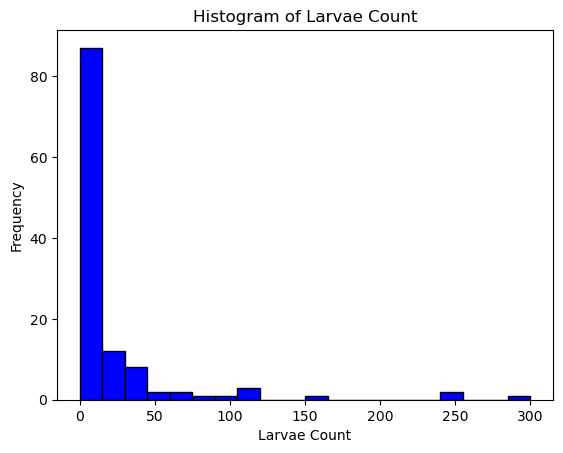

In [77]:
# Convert LarvaeCount to numeric, coercing errors to NaN
data["LarvaeCount"] = pd.to_numeric(data["LarvaeCount"], errors="coerce")
data = data.dropna(subset=["LarvaeCount"])
# Create the histogram
plt.hist(data["LarvaeCount"], bins=20, color='blue', edgecolor='black')
plt.title("Histogram of Larvae Count")
plt.xlabel("Larvae Count")
plt.ylabel("Frequency")
plt.show()

In [86]:
data[data["LarvaeCount"] != 0].shape
data = data[data["LarvaeCount"] != 0]

In [93]:
data.shape

(44, 98)

In [96]:
data["Userid"].unique()

AttributeError: 'DataFrame' object has no attribute 'unique'

In [92]:
data[data["LarvaeCount"] >50].shape

(11, 98)

<function matplotlib.pyplot.show(close=None, block=None)>

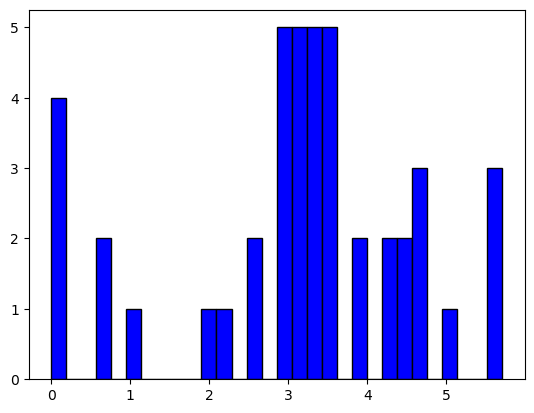

In [89]:
plt.hist(np.log(data["LarvaeCount"]), bins=30, color='blue', edgecolor='black')
plt.show